In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0, os.path.join(os.getcwd(), 'scripts'))

from ca_model import initialize_grid, update_grid, count_cells, PROLIFERATING, QUIESCENT, NECROTIC, EMPTY
from radiotherapy import fractionated_radiotherapy
from run_simulation import run_simulation

print("Importy")

Importy


In [8]:
print("Start simulation without treatment")
grid_untreated, history_untreated = run_simulation(n_steps=100, grid_size=201, treatment_start=None, seed=42)
print(f"Final number of cells: {history_untreated['total'][-1]}")

Start simulation without treatment
Final number of cells: 11763


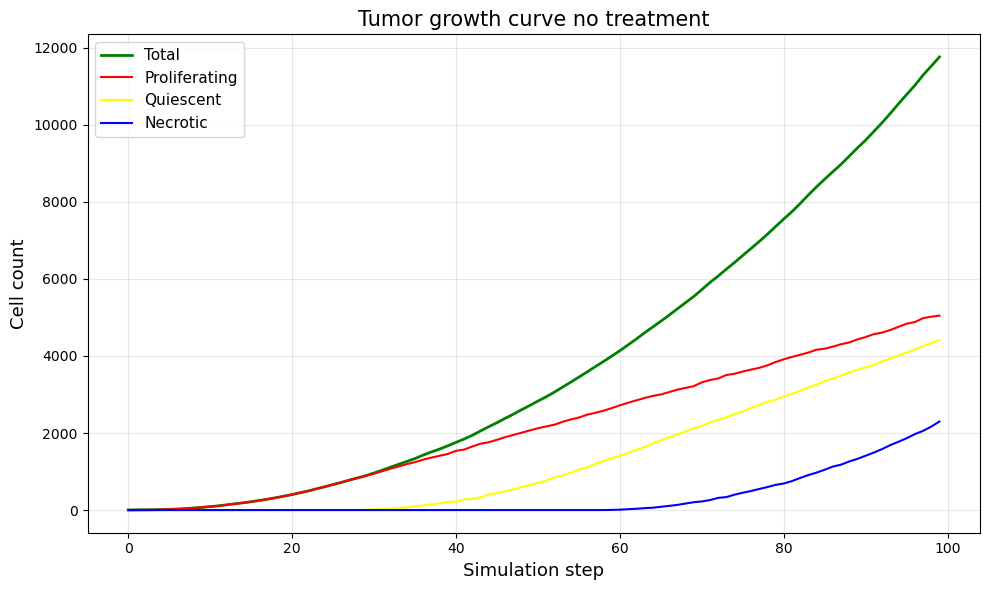

Save


In [14]:
import os
os.makedirs('../results/figures', exist_ok=True)

steps = range(100)

plt.figure(figsize=(10, 6))
plt.plot(steps, history_untreated['total'], label='Total', color='green', linewidth=2)
plt.plot(steps, history_untreated['proliferating'], label='Proliferating', color='red')
plt.plot(steps, history_untreated['quiescent'], label='Quiescent', color='yellow')
plt.plot(steps, history_untreated['necrotic'], label='Necrotic', color='blue')

plt.xlabel('Simulation step', fontsize=13)
plt.ylabel('Cell count', fontsize=13)
plt.title('Tumor growth curve no treatment', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/growth_curve_untreated.png', dpi=150)
plt.show()
print("Save")

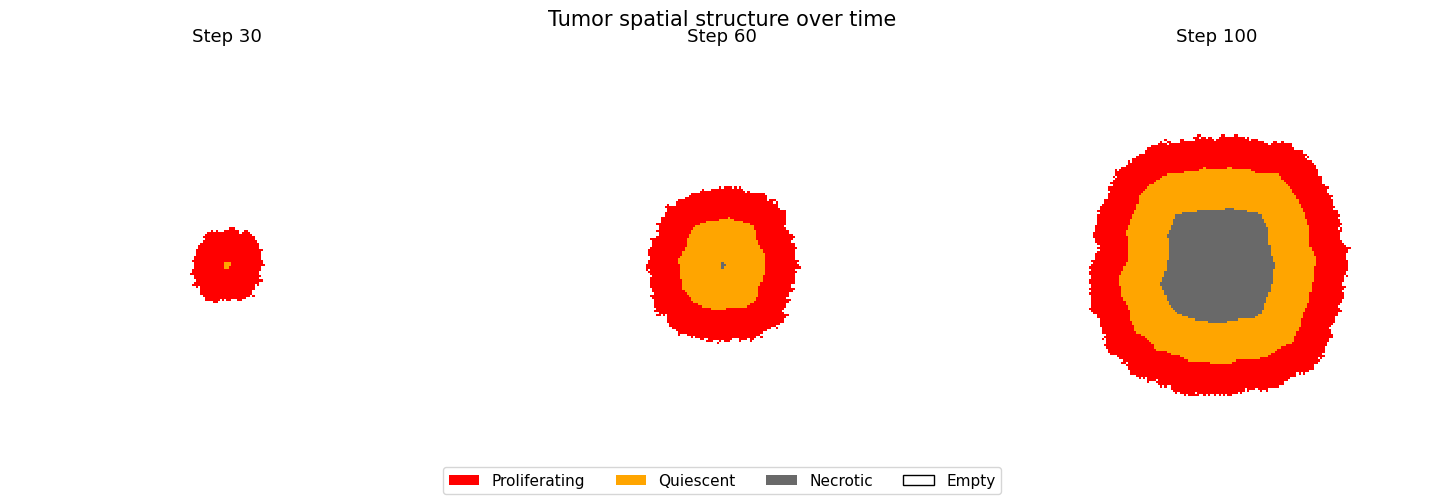

Saved


In [16]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

#puste=biały, proliferujące=czerwony, uśpione=pomarańczowy, martwe=szary
cmap = ListedColormap(['white', 'red', 'orange', 'dimgray'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, n_steps in enumerate([30, 60, 100]):
    np.random.seed(42)
    grid_snap, _ = run_simulation(n_steps=n_steps, grid_size=201, treatment_start=None, seed=42)
    
    axes[i].imshow(grid_snap, cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
    axes[i].set_title(f'Step {n_steps}', fontsize=13)
    axes[i].axis('off')

legend_elements = [
    Patch(facecolor='red', label='Proliferating'),
    Patch(facecolor='orange', label='Quiescent'),
    Patch(facecolor='dimgray', label='Necrotic'),
    Patch(facecolor='white', edgecolor='black', label='Empty')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=11)
plt.suptitle('Tumor spatial structure over time', fontsize=15)
plt.tight_layout()
plt.savefig('../results/figures/spatial_snapshots.png', dpi=150)
plt.show()
print("Saved")

In [18]:
print("Rstart of simulations")

# no treatment
grid_none, hist_none = run_simulation(n_steps=100, grid_size=201, treatment_start=None, seed=42)

# early treatment
grid_early, hist_early = run_simulation(n_steps=100, grid_size=201, treatment_start=20, seed=42)

# medium traetment
grid_mid, hist_mid = run_simulation(n_steps=100, grid_size=201, treatment_start=40, seed=42)

# late treatment
grid_late, hist_late = run_simulation(n_steps=100, grid_size=201, treatment_start=60, seed=42)

print("Done")
print(f"No treatment:    {hist_none['total'][-1]} cells")
print(f"Early (step 20): {hist_early['total'][-1]} cells")
print(f"Mid   (step 40): {hist_mid['total'][-1]} cells")
print(f"Late  (step 60): {hist_late['total'][-1]} cells")

Rstart of simulations
Done
No treatment:    11763 cells
Early (step 20): 9110 cells
Mid   (step 40): 9070 cells
Late  (step 60): 9293 cells


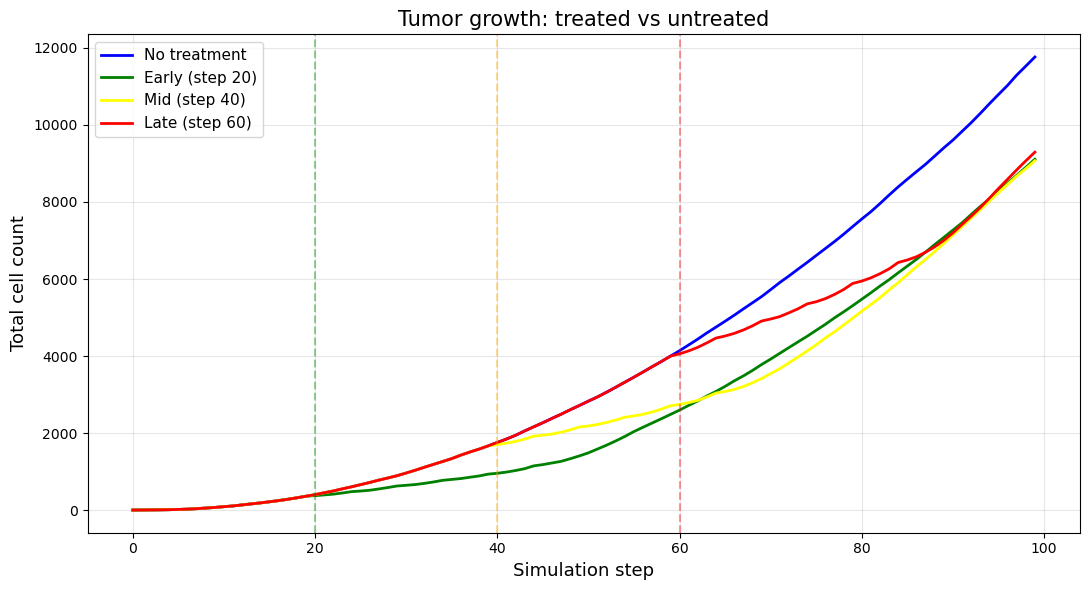

Saved


In [19]:
steps = range(100)

plt.figure(figsize=(11, 6))
plt.plot(steps, hist_none['total'],  label='No treatment',    color='blue',  linewidth=2)
plt.plot(steps, hist_early['total'], label='Early (step 20)', color='green',  linewidth=2)
plt.plot(steps, hist_mid['total'],   label='Mid (step 40)',   color='yellow', linewidth=2)
plt.plot(steps, hist_late['total'],  label='Late (step 60)',  color='red',    linewidth=2)

# moments of treatmens
plt.axvline(x=20, color='green',  linestyle='--', alpha=0.4)
plt.axvline(x=40, color='orange', linestyle='--', alpha=0.4)
plt.axvline(x=60, color='red',    linestyle='--', alpha=0.4)

plt.xlabel('Simulation step', fontsize=13)
plt.ylabel('Total cell count', fontsize=13)
plt.title('Tumor growth: treated vs untreated', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/treatment_comparison.png', dpi=150)
plt.show()
print("Saved")

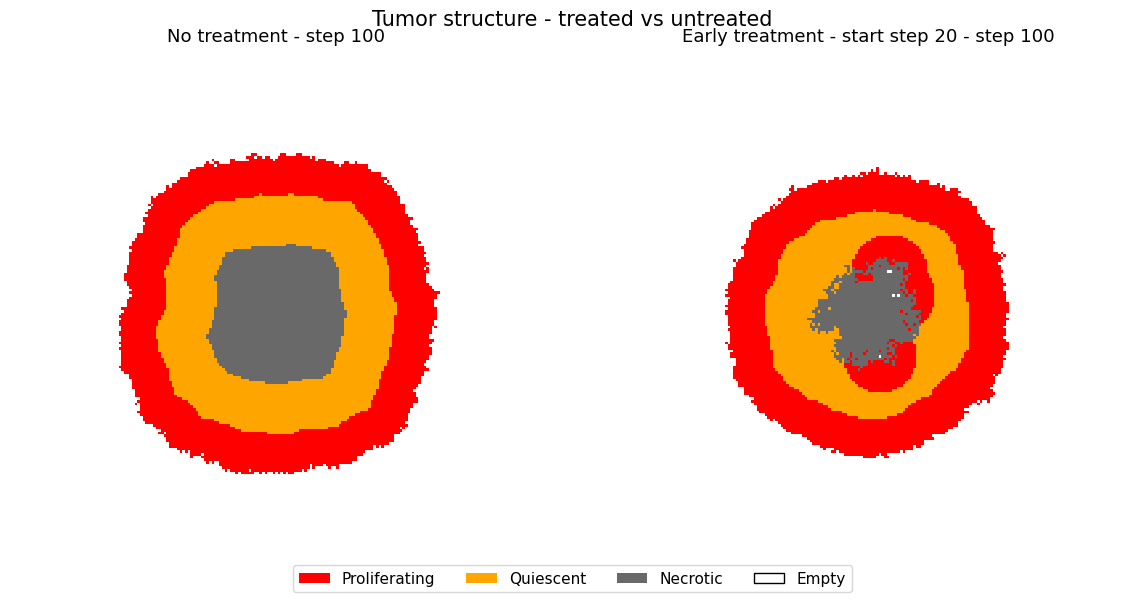

Saved


In [24]:
cmap = ListedColormap(['white', 'red', 'orange', 'dimgray'])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(grid_none, cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
axes[0].set_title('No treatment - step 100', fontsize=13)
axes[0].axis('off')

axes[1].imshow(grid_early, cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
axes[1].set_title('Early treatment - start step 20 - step 100', fontsize=13)
axes[1].axis('off')

legend_elements = [
    Patch(facecolor='red',     label='Proliferating'),
    Patch(facecolor='orange',  label='Quiescent'),
    Patch(facecolor='dimgray', label='Necrotic'),
    Patch(facecolor='white', edgecolor='black', label='Empty')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=11)
plt.suptitle('Tumor structure - treated vs untreated', fontsize=15)
plt.tight_layout()
plt.savefig('../results/figures/treated_vs_untreated.png', dpi=150)
plt.show()
print("Saved")